# Timeseries

in this model, we will learn and apply the various timeseries models

In [ ]:
# !pip install pmdarima
# !pip install pymannkendall

# 1. lets collect the timeseires data

In [1]:
# '''Import the Yahooo finance library and pandas'''

# import yfinance as yf
# import pandas as pd



# # Define ticker symbol for tesla
# ticker = "TSLA"

# # Create a Ticker object
# tsla = yf.Ticker(ticker)

# '''Interval: daily data'''
# data_tesla = tsla.history(start="2010-06-30", end="2026-10-01", interval="1d")

# # Print the first few rows
# print(data_tesla.head())



In [7]:
# Extract only the closing price column
close_prices_tesla = data_tesla["Close"]

# If you want, convert to a DataFrame with date as a column
tesla = pd.DataFrame({"Date": close_prices_tesla.index, "Close": close_prices_tesla.values})
tesla.reset_index(drop=True, inplace=True)

print(tesla.tail())

                         Date       Close
207 2026-09-24 00:00:00-04:00  377.940002
208 2026-09-25 00:00:00-04:00  372.109985
209 2026-09-28 00:00:00-04:00  357.450012
210 2026-09-29 00:00:00-04:00  352.839996
211 2026-09-30 00:00:00-04:00  354.809998


In [8]:
tesla.to_csv("tesla_stock.csv", index=False)

# 2. Analysing the Tesla Share price and Predictions

# A. Step 1: Load the data and visulize 

In [38]:
'''===========================STEP 1.1============================'''
import pandas as pd
df = pd.read_csv("tesla_stock.csv")


In [39]:
df.shape

(4088, 2)

In [40]:
df['Date'].min()

'2010-06-30 00:00:00-04:00'

In [41]:
df['Date'].max()

'2026-09-30 00:00:00-04:00'

In [42]:
df.describe()

,Close
count,4088.000000
mean,112.441252
std,136.755487
min,1.053333
25%,13.168333
50%,20.802333
75%,224.997494
max,489.880005


In [43]:
df['Date']

0       2010-06-30 00:00:00-04:00
1       2010-07-01 00:00:00-04:00
2       2010-07-02 00:00:00-04:00
3       2010-07-06 00:00:00-04:00
4       2010-07-07 00:00:00-04:00
                  ...            
4083    2026-09-24 00:00:00-04:00
4084    2026-09-25 00:00:00-04:00
4085    2026-09-28 00:00:00-04:00
4086    2026-09-29 00:00:00-04:00
4087    2026-09-30 00:00:00-04:00
Name: Date, Length: 4088, dtype: object

In [44]:
df['Date']

0       2010-06-30 00:00:00-04:00
1       2010-07-01 00:00:00-04:00
2       2010-07-02 00:00:00-04:00
3       2010-07-06 00:00:00-04:00
4       2010-07-07 00:00:00-04:00
                  ...            
4083    2026-09-24 00:00:00-04:00
4084    2026-09-25 00:00:00-04:00
4085    2026-09-28 00:00:00-04:00
4086    2026-09-29 00:00:00-04:00
4087    2026-09-30 00:00:00-04:00
Name: Date, Length: 4088, dtype: object

In [45]:
df['Date'] = pd.to_datetime(df['Date'], utc=True)


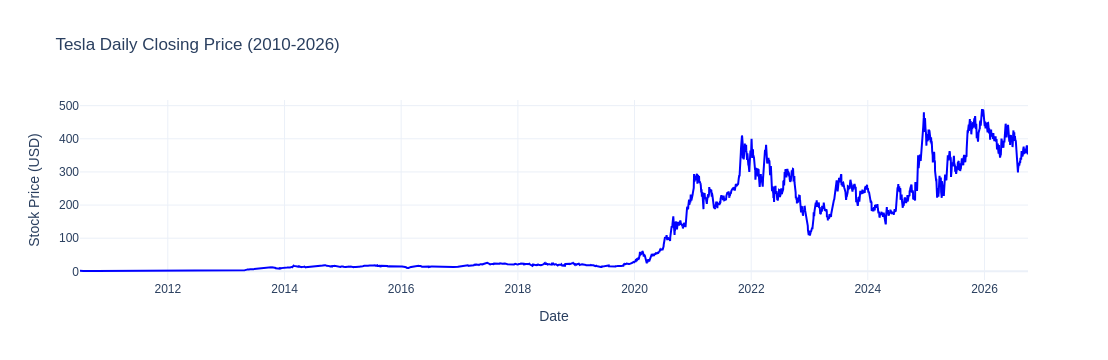

In [46]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['Close'],
    mode='lines',
    line=dict(color='blue')
))

fig.update_layout(
    title='Tesla Daily Closing Price (2010-2026)',
    xaxis_title='Date',
    yaxis_title='Stock Price (USD)',
    hovermode='x unified',
    template='plotly_white',
    showlegend=False
)

fig.show()

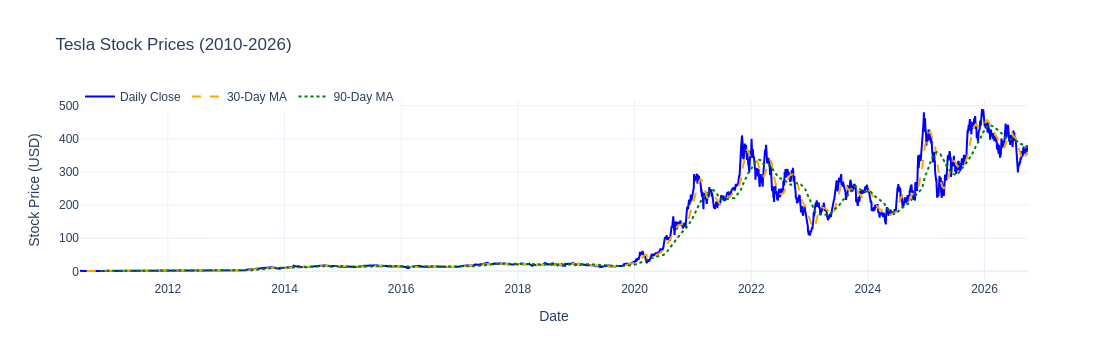

In [47]:
'''===========================STEP 1.2 ============================'''

import plotly.graph_objects as go

# Convert the date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

# Add moving averages
df['MA30'] = df['Close'].rolling(window=30).mean()
df['MA90'] = df['Close'].rolling(window=90).mean()

# Create interactive line chart
fig = go.Figure()

# Daily closing price
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['Close'],
    mode='lines',
    name='Daily Close',
    line=dict(color='blue')
))

# 30-day moving average
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['MA30'],
    mode='lines',
    name='30-Day MA',
    line=dict(color='orange', dash='dash')
))

# 90-day moving average
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['MA90'],
    mode='lines',
    name='90-Day MA',
    line=dict(color='green', dash='dot')
))

# Layout customization
fig.update_layout(
    title='Tesla Stock Prices (2010-2026)',
    xaxis_title='Date',
    yaxis_title='Stock Price (USD)',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(x=0, y=1.1, orientation='h')
)

fig.show()

# Step 2: Analyzing the trends in data

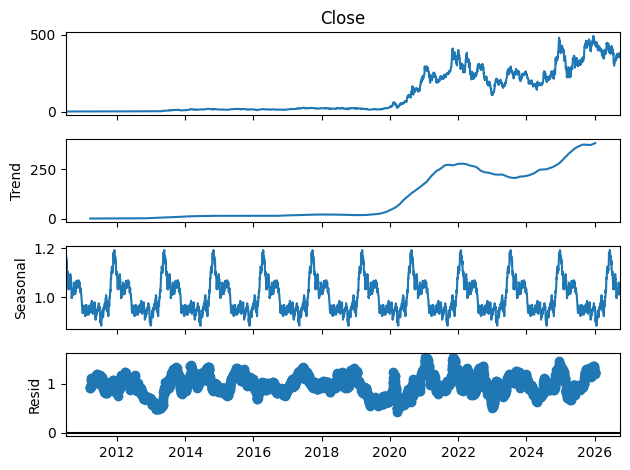

In [48]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Set date as index
df_ts = df.set_index('Date')

# Decompose (daily frequency)
result = seasonal_decompose(df_ts['Close'], model='multiplicative', period=365)

# Plot
result.plot()
plt.show()


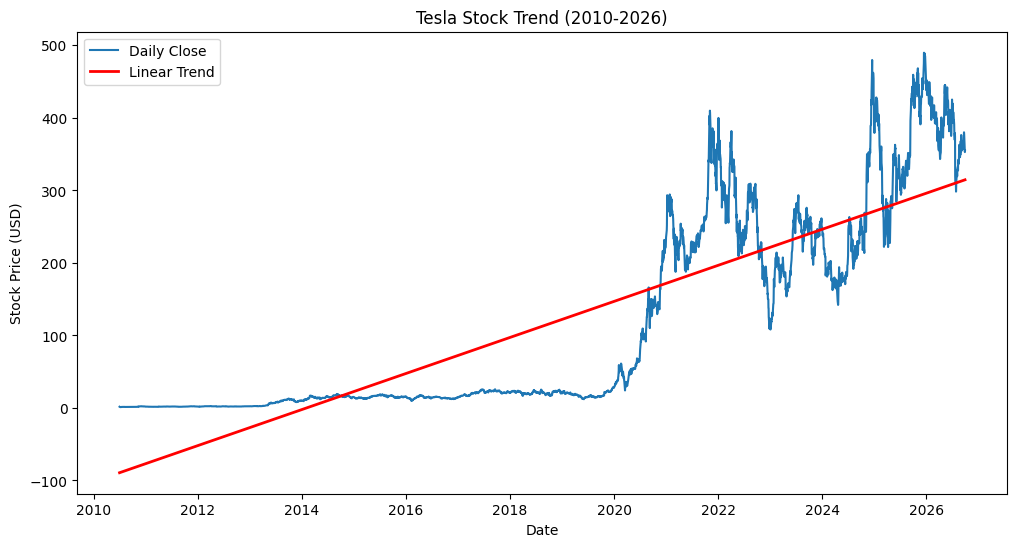

In [49]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Convert dates to ordinal numbers for regression
X = df['Date'].map(pd.Timestamp.toordinal).values.reshape(-1,1)
y = df['Close'].values

model = LinearRegression()
model.fit(X, y)
trend = model.predict(X)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(df['Date'], y, label='Daily Close')
plt.plot(df['Date'], trend, color='red', linewidth=2, label='Linear Trend')
plt.title('Tesla Stock Trend (2010-2026)')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.show()


In [50]:
import pymannkendall as mk

trend_test = mk.original_test(df['Close'])
print(trend_test)


Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(77.47307731303826), Tau=np.float64(0.808146397076885), s=np.float64(6751116.0), var_s=np.float64(7593629399.333333), slope=np.float64(0.0779429848397822), intercept=np.float64(-138.47415664198212))


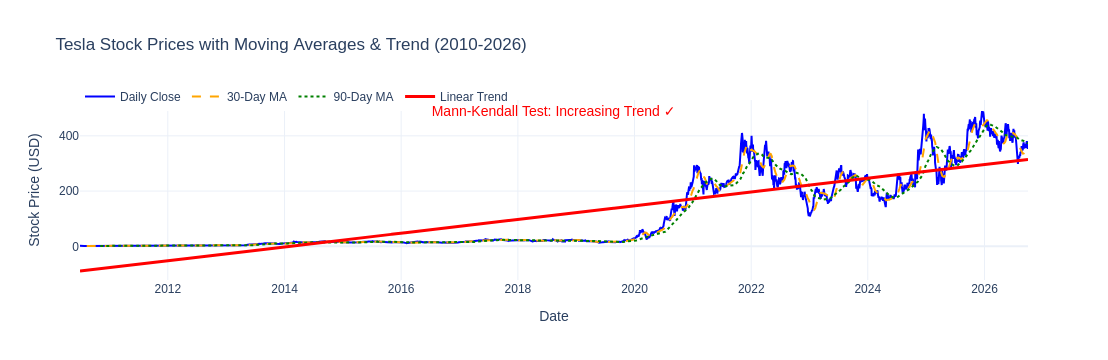

In [51]:
import plotly.graph_objects as go
import pandas as pd
from sklearn.linear_model import LinearRegression

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

# Prepare data for linear trend
X = df['Date'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
y = df['Close'].values

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Calculate trend values
trend = model.predict(X)

# Create figure
fig = go.Figure()

# Daily closing price
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['Close'],
    mode='lines',
    name='Daily Close',
    line=dict(color='blue')
))

# 30-day moving average
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['MA30'],
    mode='lines',
    name='30-Day MA',
    line=dict(color='orange', dash='dash')
))

# 90-day moving average
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['MA90'],
    mode='lines',
    name='90-Day MA',
    line=dict(color='green', dash='dot')
))

# Linear regression trend line
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=trend,
    mode='lines',
    name='Linear Trend',
    line=dict(color='red', width=3)
))

# Mann-Kendall annotation
fig.add_annotation(
    x=df['Date'].iloc[len(df) // 2],
    y=df['Close'].max(),
    text='Mann-Kendall Test: Increasing Trend ✓',
    showarrow=False,
    font=dict(size=14, color='red')
)

# Layout
fig.update_layout(
    title='Tesla Stock Prices with Moving Averages & Trend (2010-2026)',
    xaxis_title='Date',
    yaxis_title='Stock Price (USD)',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(x=0, y=1.1, orientation='h')
)

fig.show()

# Step 3: Detrending the data 

In [52]:
'''Detrending using differening'''

df['Close_diff'] = df['Close'].diff()  # simple daily difference


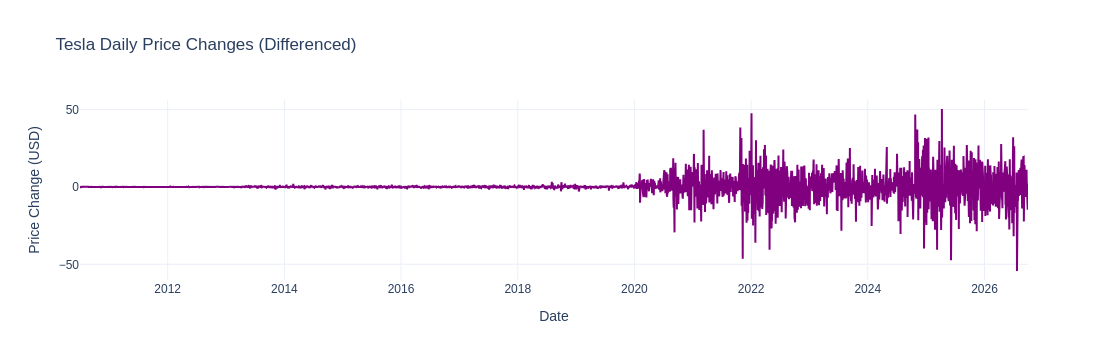

In [53]:
import plotly.graph_objects as go

# Drop the first NaN from differencing
df_diff = df['Close_diff'].dropna()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['Date'].iloc[1:],
    y=df_diff,
    mode='lines',
    name='Daily Difference',
    line=dict(color='purple')
))

fig.update_layout(
    title='Tesla Daily Price Changes (Differenced)',
    xaxis_title='Date',
    yaxis_title='Price Change (USD)',
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

# Step 4: Staitionarity of data

In [54]:
from statsmodels.tsa.stattools import adfuller

# Drop NaN from differencing
df_diff = df['Close'].dropna()

# Perform ADF test
adf_result = adfuller(df_diff)

print("ADF Statistic: {:.4f}".format(adf_result[0]))
print("p-value: {:.4f}".format(adf_result[1]))
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")


ADF Statistic: -1.1284
p-value: 0.7036
Critical Values:
   1%: -3.4320
   5%: -2.8623
   10%: -2.5671


/tmp/ipykernel_716163/2213345599.py:7: FutureWarning:

adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.



In [55]:
from statsmodels.tsa.stattools import adfuller

# Drop NaN from differencing
df_diff = df['Close_diff'].dropna()

# Perform ADF test
adf_result = adfuller(df_diff)

print("ADF Statistic: {:.4f}".format(adf_result[0]))
print("p-value: {:.4f}".format(adf_result[1]))
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")


ADF Statistic: -11.8721
p-value: 0.0000
Critical Values:
   1%: -3.4320
   5%: -2.8623
   10%: -2.5671


/tmp/ipykernel_716163/285659092.py:7: FutureWarning:

adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.



# Step 5: lags Selections

In [56]:
import pmdarima as pm
import pandas as pd

# Use ORIGINAL series (not differenced)
ts = df['Close'].dropna()

criteria = ['aic', 'bic', 'hqic', 'aicc']
best_orders = {}

for crit in criteria:
    model = pm.auto_arima(
        ts,
        start_p=0, max_p=10,
        start_q=0, max_q=10,
        d=None,            # Let auto_arima determine differencing
        max_d=2,           # Maximum differencing order
        seasonal=False,
        information_criterion=crit,
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        trace=False        # Set to True if you want to see the search process
    )
    best_orders[crit.upper()] = model.order

# Convert to DataFrame
best_orders_df = pd.DataFrame(best_orders).T
best_orders_df.columns = ['p', 'd', 'q']

print(best_orders_df)

      p  d  q
AIC   1  1  0
BIC   0  1  0
HQIC  0  1  0
AICC  1  1  0


In [57]:
import pmdarima as pm
import pandas as pd

# Stationary series
ts = df['Close_diff'].dropna()

# Criteria list
criteria = ['aic', 'bic', 'hqic', 'aicc']
best_orders = {}

for crit in criteria:
    model = pm.auto_arima(
        ts,
        start_p=0, max_p=10,
        start_q=0, max_q=10,
        d=0,               # already differenced
        seasonal=False,    # ARMA
        information_criterion=crit,
        stepwise=True,     # fast stepwise search
        suppress_warnings=True,
        error_action='ignore'
    )
    best_orders[crit.upper()] = model.order  # tuple (p,d,q)

# Convert to DataFrame with separate columns
best_orders_df = pd.DataFrame(best_orders).T  # transpose
best_orders_df.columns = ['p','d','q']

print(best_orders_df)


      p  d  q
AIC   1  0  0
BIC   0  0  0
HQIC  1  0  0
AICC  1  0  0


# Step 8: Fitting the Model

# Original Model-

In [58]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# Stationary series
ts = df['Close_diff'].dropna()

# Fit ARMA/ARIMA model (ARIMA(1,0,0))
model = sm.tsa.ARIMA(ts, order=(1,0,0))
result = model.fit()

print(result.summary())




                               SARIMAX Results                                
Dep. Variable:             Close_diff   No. Observations:                 4087
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -13340.681
Date:                Fri, 02 Oct 2026   AIC                          26687.362
Time:                        16:37:25   BIC                          26706.309
Sample:                             0   HQIC                         26694.071
                               - 4087                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0864      0.096      0.904      0.366      -0.101       0.274
ar.L1         -0.0367      0.009     -4.206      0.000      -0.054      -0.020
sigma2        40.0708      0.337    118.751      0.0

/home/jahmed/anaconda3/envs/hospital/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.

/home/jahmed/anaconda3/envs/hospital/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.

/home/jahmed/anaconda3/envs/hospital/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.



# White Noice Model:

What will happen if we compare our original model againts the No Lag model?

In [59]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

ts = df['Close_diff'].dropna()

# Compare both models
models_to_test = {
    'ARMA(0,0) - White Noise': (0, 0, 0),
    'ARMA(1,0) - AR(1)': (1, 0, 0)
}

results_comparison = []

for name, order in models_to_test.items():
    model = sm.tsa.ARIMA(ts, order=order)
    result = model.fit()
    
    # Ljung-Box test on residuals (p > 0.05 means residuals are white noise - good!)
    lb_test = acorr_ljungbox(result.resid, lags=10, return_df=True)
    
    results_comparison.append({
        'Model': name,
        'AIC': result.aic,
        'BIC': result.bic,
        'HQIC': result.hqic,
        'AICC': result.aicc,
        'Ljung-Box p-value (lag 10)': lb_test['lb_pvalue'].iloc[-1]
    })
    
    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(result.summary())

# Compare models
import pandas as pd
comparison_df = pd.DataFrame(results_comparison)
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

/home/jahmed/anaconda3/envs/hospital/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.

/home/jahmed/anaconda3/envs/hospital/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.

/home/jahmed/anaconda3/envs/hospital/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.




ARMA(0,0) - White Noise
                               SARIMAX Results                                
Dep. Variable:             Close_diff   No. Observations:                 4087
Model:                          ARIMA   Log Likelihood              -13343.453
Date:                Fri, 02 Oct 2026   AIC                          26690.905
Time:                        16:37:25   BIC                          26703.536
Sample:                             0   HQIC                         26695.378
                               - 4087                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0864      0.099      0.872      0.383      -0.108       0.281
sigma2        40.1181      0.338    118.667      0.000      39.455      40.781
Ljung-Box (L1) (Q):        

/home/jahmed/anaconda3/envs/hospital/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.

/home/jahmed/anaconda3/envs/hospital/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.

/home/jahmed/anaconda3/envs/hospital/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.



ARMA(1,0) + GARCH(1,1)

# Pure GARCH Model

In [60]:
from arch import arch_model

# Pure GARCH without AR term
model = arch_model(
    ts, 
    mean='Constant',  # Just a constant, no AR
    vol='GARCH',
    p=1, q=1,
    dist='t'          # Student-t for fat tails
)
result = model.fit(disp='off')
print(result.summary())

print("mu: mean return → average daily return of the series")
print("omega: base volatility → long-run variance floor, minimum level of volatility")
print("alpha: shock impact → effect of yesterday's return shocks on today's volatility")
print("beta: volatility persistence → effect of yesterday's volatility on today's volatility")
print("nu: fat-tail parameter → allows for extreme returns beyond normal distribution")


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   Close_diff   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -6045.23
Distribution:      Standardized Student's t   AIC:                           12100.5
Method:                  Maximum Likelihood   BIC:                           12132.0
                                              No. Observations:                 4087
Date:                      Fri, Oct 02 2026   Df Residuals:                     4086
Time:                              16:37:26   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
m

# Step 9: Model diagnostic

In [61]:
# 1. Standardized residuals should be white noise
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Extract standardized residuals
std_resid = result.resid / result.resid.std()


# 2. Ljung-Box test
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(std_resid, lags=10, return_df=True)
print("\nLjung-Box Test: Autocorrelation (p > 0.05 is good):")
print(lb_test)


# 3. ARCH-LM test (no remaining ARCH effects)
from statsmodels.stats.diagnostic import het_arch
arch_test = het_arch(result.resid, nlags=10)
print(f"\nARCH-LM Test statistic: {arch_test[0]:.4f}, p-value: {arch_test[1]:.4f}")
print("(p > 0.05 → no remaining ARCH effects)")
print("If p-value is below 0.05, the model may need higher-order GARCH terms. This suggests that there exists higher-order volatility clustering in the residuals.")



Ljung-Box Test: Autocorrelation (p > 0.05 is good):
      lb_stat  lb_pvalue
1    5.544582   0.018538
2    5.640970   0.059577
3    5.818676   0.120773
4    5.819834   0.213013
5    5.878064   0.318265
6    6.931688   0.327211
7   12.583714   0.082924
8   13.944576   0.083222
9   24.039223   0.004240
10  27.492075   0.002176

ARCH-LM Test statistic: 507.4461, p-value: 0.0000
(p > 0.05 → no remaining ARCH effects)
If p-value is below 0.05, the model may need higher-order GARCH terms. This suggests that there exists higher-order volatility clustering in the residuals.


/home/jahmed/anaconda3/envs/hospital/lib/python3.10/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning:

acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.



# Step 10: IRF

    Day  Forecasted_Price  Volatility  Upper_1sigma  Lower_1sigma  \
0     1        354.813219    9.878133    364.691353    344.935086   
1     2        354.816441    9.878111    364.694552    344.938330   
2     3        354.819663    9.878089    364.697752    344.941573   
3     4        354.822884    9.878067    364.700952    344.944817   
4     5        354.826106    9.878045    364.704151    344.948061   
5     6        354.829328    9.878023    364.707351    344.951305   
6     7        354.832549    9.878001    364.710550    344.954548   
7     8        354.835771    9.877979    364.713750    344.957792   
8     9        354.838993    9.877957    364.716950    344.961036   
9    10        354.842214    9.877935    364.720149    344.964279   
10   11        354.845436    9.877913    364.723349    344.967523   
11   12        354.848658    9.877891    364.726549    344.970767   
12   13        354.851879    9.877869    364.729748    344.974010   
13   14        354.855101    9.877

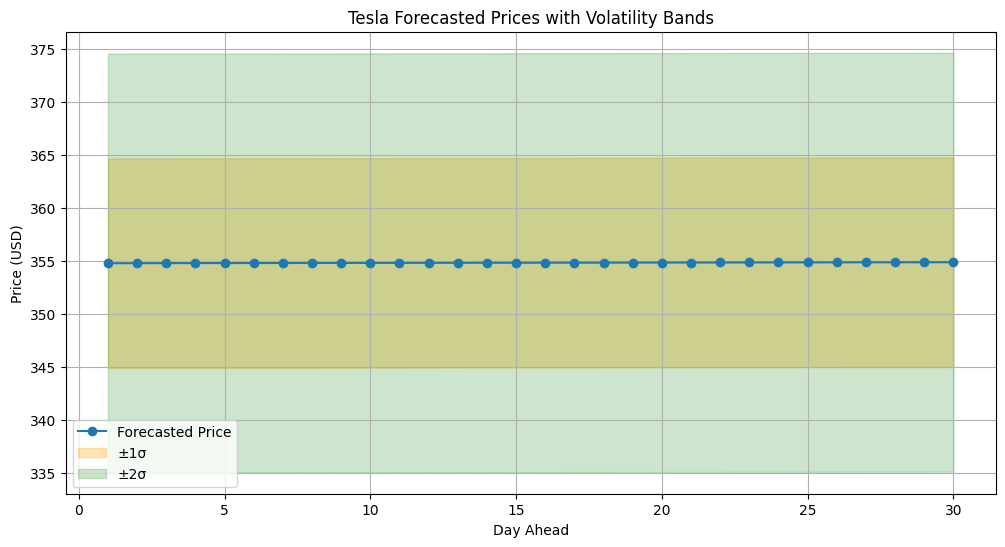

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Forecast horizon
horizon = 30  # next 30 days

# Forecast using fitted GARCH model
forecast = result.forecast(horizon=horizon)

# Extract mean forecast (returns) and conditional volatility
mean_forecast = forecast.mean.values[-1, :]  # predicted daily changes
vol_forecast = np.sqrt(forecast.variance.values[-1, :])  # conditional std dev

# Reconstruct forecasted prices from last known closing price
last_price = df['Close'].iloc[-1]
price_forecast = [last_price]
for ret in mean_forecast:
    price_forecast.append(price_forecast[-1] + ret)

price_forecast = price_forecast[1:]  # remove initial last price

# Create DataFrame
forecast_df = pd.DataFrame({
    'Day': range(1, horizon+1),
    'Forecasted_Price': price_forecast,
    'Volatility': vol_forecast
})

# Compute 1-sigma and 2-sigma bands
forecast_df['Upper_1sigma'] = forecast_df['Forecasted_Price'] + forecast_df['Volatility']
forecast_df['Lower_1sigma'] = forecast_df['Forecasted_Price'] - forecast_df['Volatility']
forecast_df['Upper_2sigma'] = forecast_df['Forecasted_Price'] + 2*forecast_df['Volatility']
forecast_df['Lower_2sigma'] = forecast_df['Forecasted_Price'] - 2*forecast_df['Volatility']

# Display forecast table
print(forecast_df)

# Plot forecast with volatility bands
plt.figure(figsize=(12,6))
plt.plot(forecast_df['Day'], forecast_df['Forecasted_Price'], marker='o', label='Forecasted Price')
plt.fill_between(forecast_df['Day'], forecast_df['Lower_1sigma'], forecast_df['Upper_1sigma'], color='orange', alpha=0.3, label='±1σ')
plt.fill_between(forecast_df['Day'], forecast_df['Lower_2sigma'], forecast_df['Upper_2sigma'], color='green', alpha=0.2, label='±2σ')
plt.title("Tesla Forecasted Prices with Volatility Bands")
plt.xlabel("Day Ahead")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


In [22]:
# Forecast next 10 days of volatility
forecasts = result.forecast(horizon=10)

# Extract volatility forecasts
volatility_forecast = np.sqrt(forecasts.variance.values[-1, :])

print("Forecasted Daily Volatility (%):")
for i, vol in enumerate(volatility_forecast, 1):
    print(f"Day {i}: {vol:.2f}%")

Forecasted Daily Volatility (%):
Day 1: 9.88%
Day 2: 9.88%
Day 3: 9.88%
Day 4: 9.88%
Day 5: 9.88%
Day 6: 9.88%
Day 7: 9.88%
Day 8: 9.88%
Day 9: 9.88%
Day 10: 9.88%


In [23]:
import scipy.stats as stats

# 95% VaR for tomorrow
current_price = df['Close'].iloc[-1]
tomorrow_vol = np.sqrt(forecasts.variance.values[-1, 0])

# Student-t quantile (not normal!)
t_quantile = stats.t.ppf(0.05, df=4.53)
VaR_95 = current_price * tomorrow_vol * t_quantile

print(f"\nCurrent Tesla Price: ${current_price:.2f}")
print(f"Tomorrow's Volatility: {tomorrow_vol:.2f}%")
print(f"95% VaR: ${abs(VaR_95):.2f}")
print(f"Maximum expected loss (95% confidence): {abs(VaR_95)/current_price*100:.2f}%")


Current Tesla Price: $354.81
Tomorrow's Volatility: 9.88%
95% VaR: $7227.59
Maximum expected loss (95% confidence): 2037.03%


In [24]:
# Risk-adjusted position sizing
account_value = 100000  # $100k account
max_risk_per_trade = 0.02  # 2% max risk

# Use forecasted volatility
next_day_vol = np.sqrt(forecasts.variance.values[-1, 0])

# Position size to risk 2% at 1 standard deviation
position_size = (account_value * max_risk_per_trade) / (current_price * next_day_vol / 100)

print(f"\nSuggested position size: {position_size:.0f} shares")
print(f"Total investment: ${position_size * current_price:,.2f}")


Suggested position size: 57 shares
Total investment: $20,246.74


# Step 12: Simpler model with no any ARCH and GARCH

In [41]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

#use Close prices
ts = df['Close_diff']

# =========================
# Fit simple ARIMA model
# =========================
# Let's use the AIC suggested order: (p=1, d=1, q=0)
model = ARIMA(ts, order=(1, 1, 0))  # ARIMA(1,1,0)
result = model.fit()

# Print summary
print(result.summary())



                               SARIMAX Results                                
Dep. Variable:             Close_diff   No. Observations:                 4088
Model:                 ARIMA(1, 1, 0)   Log Likelihood              -14194.258
Date:                Thu, 01 Oct 2026   AIC                          28392.517
Time:                        10:58:23   BIC                          28405.148
Sample:                             0   HQIC                         28396.989
                               - 4088                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5200      0.006    -82.234      0.000      -0.532      -0.508
sigma2        60.7144      0.542    111.983      0.000      59.652      61.777
Ljung-Box (L1) (Q):                 124.87   Jarque-

# DF_CLose

                               SARIMAX Results                                
Dep. Variable:             Close_diff   No. Observations:                 4087
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -13340.681
Date:                Fri, 02 Oct 2026   AIC                          26687.362
Time:                        16:40:11   BIC                          26706.309
Sample:                             0   HQIC                         26694.071
                               - 4087                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0864      0.096      0.904      0.366      -0.101       0.274
ar.L1         -0.0367      0.009     -4.206      0.000      -0.054      -0.020
sigma2        40.0708      0.337    118.751      0.0

/home/jahmed/anaconda3/envs/hospital/lib/python3.10/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning:

acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.



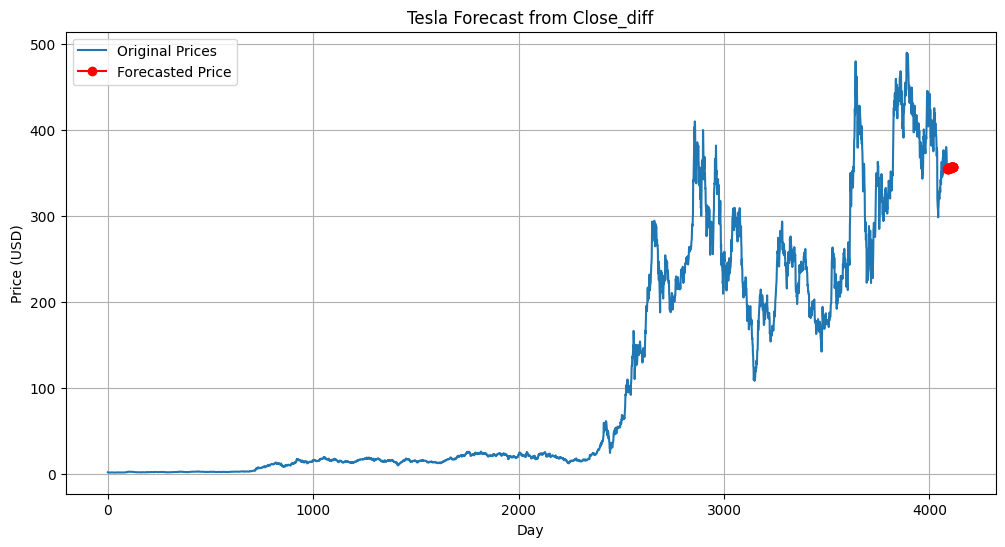


Current Tesla Price: $354.81
Estimated residual volatility: $6.3304
95% VaR (simplified, teaching): $13.50


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import scipy.stats as stats

# =========================
# 1. Fit ARIMA(1,0,0) on Close_diff
# =========================
ts = df['Close_diff'].dropna().reset_index(drop=True)

model = ARIMA(ts, order=(1,0,0))
result = model.fit()

print(result.summary())

# =========================
# 2. Residual diagnostics
# =========================
resid = result.resid
std_resid = resid / resid.std()

# Ljung-Box test
lb_test = acorr_ljungbox(std_resid, lags=10, return_df=True)

print("\nLjung-Box Test (p > 0.05 → no significant autocorrelation):")
print(lb_test)

# ARCH-LM test
arch_test = het_arch(resid, nlags=10)

print(f"\nARCH-LM Test statistic: {arch_test[0]:.4f}")
print(f"ARCH-LM p-value: {arch_test[1]:.4f}")
print("(p > 0.05 → no significant ARCH effects)")

# =========================
# 3. Forecast next 30 days
# =========================
horizon = 30

forecast = result.get_forecast(steps=horizon)
mean_forecast = forecast.predicted_mean.values

# Reconstruct forecasted prices
last_price = df['Close'].iloc[-1]

price_forecast = [last_price]

for change in mean_forecast:
    price_forecast.append(price_forecast[-1] + change)

price_forecast = price_forecast[1:]

# Forecast DataFrame
forecast_df = pd.DataFrame({
    'Day': range(1, horizon + 1),
    'Forecasted_Price': price_forecast
})

print("\n30-Day Forecast:")
print(forecast_df)

# =========================
# 4. Plot forecast
# =========================
plt.figure(figsize=(12,6))

plt.plot(
    df['Close'].values,
    label='Original Prices'
)

plt.plot(
    range(len(df['Close']), len(df['Close']) + horizon),
    price_forecast,
    marker='o',
    color='red',
    label='Forecasted Price'
)

plt.title("Tesla Forecast from Close_diff")
plt.xlabel("Day")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# 5. Simplified VaR
# =========================
current_price = df['Close'].iloc[-1]

# Residual standard deviation in USD
resid_vol = resid.std()

# Student-t quantile
t_quantile = stats.t.ppf(0.05, df=4)

# Simplified 95% VaR
VaR_95 = current_price * (resid_vol / current_price) * t_quantile

print(f"\nCurrent Tesla Price: ${current_price:.2f}")
print(f"Estimated residual volatility: ${resid_vol:.4f}")
print(f"95% VaR (simplified, teaching): ${abs(VaR_95):.2f}")

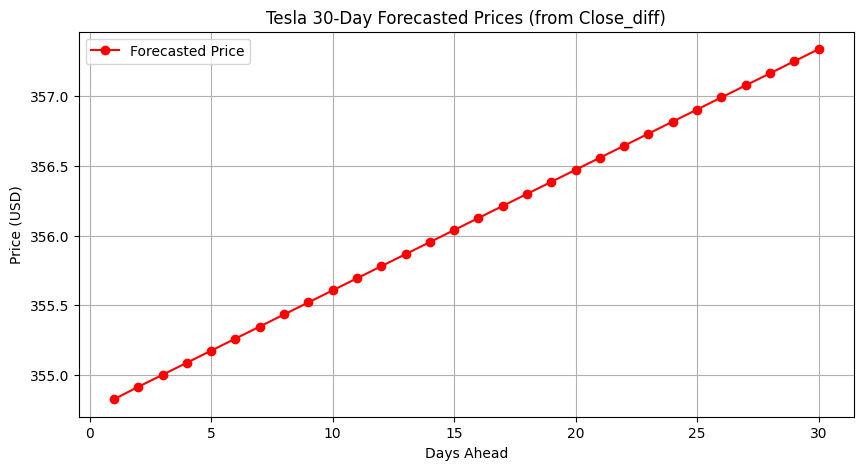

In [33]:
import matplotlib.pyplot as plt

# Separate 30-day forecast plot
plt.figure(figsize=(10,5))
plt.plot(forecast_df['Day'], forecast_df['Forecasted_Price'], marker='o', linestyle='-', color='red', label='Forecasted Price')
plt.title("Tesla 30-Day Forecasted Prices (from Close_diff)")
plt.xlabel("Days Ahead")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.show()


# Now Lets Move to Machine Learning Model

In [31]:
df

,Date,Close,MA30,MA90,Close_diff
0,2010-06-30 04:00:00+00:00,1.588667,NaN,NaN,NaN
1,2010-07-01 04:00:00+00:00,1.464000,NaN,NaN,-0.124667
2,2010-07-02 04:00:00+00:00,1.280000,NaN,NaN,-0.184000
3,2010-07-06 04:00:00+00:00,1.074000,NaN,NaN,-0.206000
4,2010-07-07 04:00:00+00:00,1.053333,NaN,NaN,-0.020667
...,...,...,...,...,...
4083,2026-09-24 04:00:00+00:00,377.940002,358.630664,374.681554,-2.179993
4084,2026-09-25 04:00:00+00:00,372.109985,359.702331,374.260665,-5.830017
4085,2026-09-28 04:00:00+00:00,357.450012,360.208331,373.742221,-14.659973
4086,2026-09-29 04:00:00+00:00,352.839996,360.659665,373.026443,-4.610016


Train size: 4005, Test size: 82

BASELINE 1: STATIC FORECAST
RMSE: $12.70
MAE:  $9.12
MAPE: 100.32%

BASELINE 2: ROLLING FORECAST
Progress: 10/82 forecasts completed
Progress: 20/82 forecasts completed
Progress: 30/82 forecasts completed
Progress: 40/82 forecasts completed
Progress: 50/82 forecasts completed
Progress: 60/82 forecasts completed
Progress: 70/82 forecasts completed
Progress: 80/82 forecasts completed

RMSE: $12.65
MAE:  $9.11
MAPE: 99.57%

BASELINE 3: NAIVE FORECAST
RMSE: $19.43
MAE:  $14.49
MAPE: 281.24%

BASELINE COMPARISON
             Model      RMSE       MAE   MAPE (%)
Naive (Last Value) 19.432666 14.489388 281.242871
      ARIMA Static 12.704814  9.122866 100.320492
     ARIMA Rolling 12.651464  9.105957  99.573150


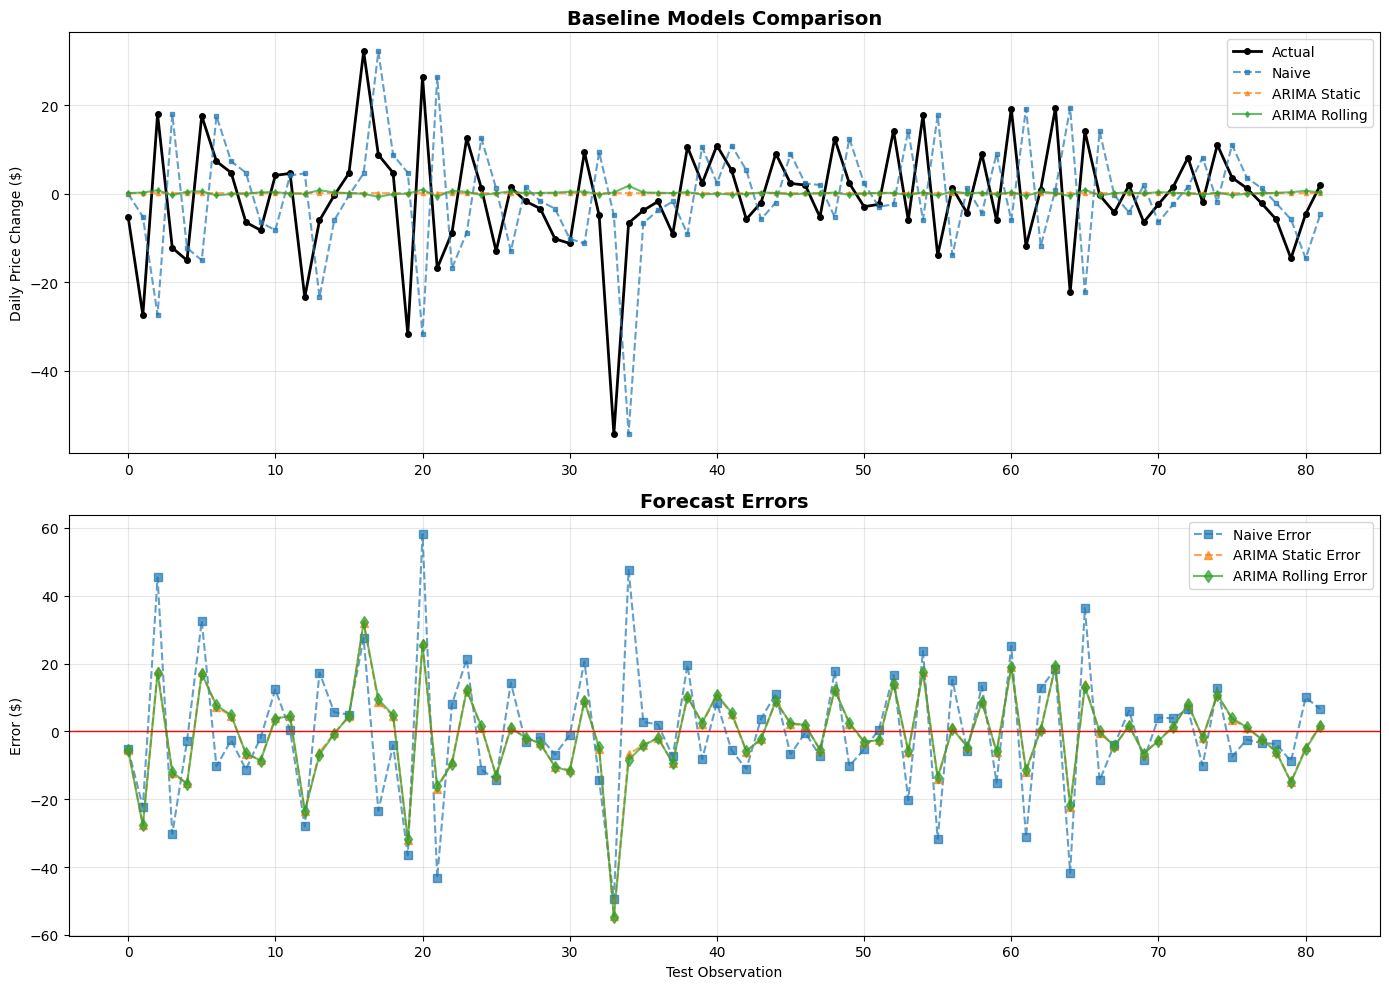


BASELINE RESULTS SAVED!


In [35]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# ===============================
# PREPARE DATA
# ===============================
series = df['Close_diff'].dropna().reset_index(drop=True)

# Train-test split (98/2)
train_size = int(len(series) * 0.98)

train = series.iloc[:train_size].reset_index(drop=True)
test = series.iloc[train_size:].reset_index(drop=True)

print(f"Train size: {len(train)}, Test size: {len(test)}")

# ===============================
# HELPER FUNCTIONS
# ===============================
def calculate_metrics(actual, pred):
    actual = np.asarray(actual)
    pred = np.asarray(pred)

    mask = np.isfinite(actual) & np.isfinite(pred)

    actual = actual[mask]
    pred = pred[mask]

    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)

    # Avoid division by zero for MAPE
    nonzero = actual != 0
    mape = np.mean(
        np.abs((actual[nonzero] - pred[nonzero]) / actual[nonzero])
    ) * 100

    return rmse, mae, mape


# ===============================
# BASELINE 1: STATIC ARIMA
# ===============================
print("\n" + "="*70)
print("BASELINE 1: STATIC FORECAST")
print("="*70)

# Close_diff is already differenced
model_static = ARIMA(train, order=(1,0,0))
result_static = model_static.fit()

forecast_static = result_static.forecast(steps=len(test))

pred_static = np.asarray(forecast_static)

rmse_static, mae_static, mape_static = calculate_metrics(
    test, pred_static
)

print(f"RMSE: ${rmse_static:.2f}")
print(f"MAE:  ${mae_static:.2f}")
print(f"MAPE: {mape_static:.2f}%")


# ===============================
# BASELINE 2: ROLLING ARIMA
# ===============================
print("\n" + "="*70)
print("BASELINE 2: ROLLING FORECAST")
print("="*70)

predictions_rolling = []

history = train.tolist()

for t in range(len(test)):

    model_rolling = ARIMA(
        history,
        order=(1,0,0)
    )

    result_rolling = model_rolling.fit()

    forecast = result_rolling.forecast(steps=1)[0]

    predictions_rolling.append(forecast)

    # Add actual observation to history
    history.append(test.iloc[t])

    if (t + 1) % 10 == 0:
        print(
            f"Progress: {t+1}/{len(test)} forecasts completed"
        )

pred_rolling = np.asarray(predictions_rolling)

rmse_rolling, mae_rolling, mape_rolling = calculate_metrics(
    test, pred_rolling
)

print(f"\nRMSE: ${rmse_rolling:.2f}")
print(f"MAE:  ${mae_rolling:.2f}")
print(f"MAPE: {mape_rolling:.2f}%")


# ===============================
# BASELINE 3: NAIVE FORECAST
# ===============================
print("\n" + "="*70)
print("BASELINE 3: NAIVE FORECAST")
print("="*70)

# For Close_diff, naive forecast = previous observed difference
pred_naive = np.empty(len(test))

pred_naive[0] = train.iloc[-1]

if len(test) > 1:
    pred_naive[1:] = test.iloc[:-1].values

rmse_naive, mae_naive, mape_naive = calculate_metrics(
    test, pred_naive
)

print(f"RMSE: ${rmse_naive:.2f}")
print(f"MAE:  ${mae_naive:.2f}")
print(f"MAPE: {mape_naive:.2f}%")


# ===============================
# COMPARISON TABLE
# ===============================
print("\n" + "="*70)
print("BASELINE COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': [
        'Naive (Last Value)',
        'ARIMA Static',
        'ARIMA Rolling'
    ],
    'RMSE': [
        rmse_naive,
        rmse_static,
        rmse_rolling
    ],
    'MAE': [
        mae_naive,
        mae_static,
        mae_rolling
    ],
    'MAPE (%)': [
        mape_naive,
        mape_static,
        mape_rolling
    ]
})

print(comparison_df.to_string(index=False))


# ===============================
# VISUALIZATION
# ===============================
test_index = np.arange(len(test))

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 10)
)

# Forecast comparison
axes[0].plot(
    test_index,
    test,
    'o-',
    linewidth=2,
    markersize=4,
    label='Actual',
    color='black'
)

axes[0].plot(
    test_index,
    pred_naive,
    's--',
    linewidth=1.5,
    markersize=3,
    label='Naive',
    alpha=0.7
)

axes[0].plot(
    test_index,
    pred_static,
    '^--',
    linewidth=1.5,
    markersize=3,
    label='ARIMA Static',
    alpha=0.7
)

axes[0].plot(
    test_index,
    pred_rolling,
    'd-',
    linewidth=1.5,
    markersize=3,
    label='ARIMA Rolling',
    alpha=0.7
)

axes[0].set_title(
    'Baseline Models Comparison',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_ylabel('Daily Price Change ($)')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)


# Forecast errors
error_naive = test.values - pred_naive
error_static = test.values - pred_static
error_rolling = test.values - pred_rolling

axes[1].plot(
    test_index,
    error_naive,
    's--',
    label='Naive Error',
    alpha=0.7
)

axes[1].plot(
    test_index,
    error_static,
    '^--',
    label='ARIMA Static Error',
    alpha=0.7
)

axes[1].plot(
    test_index,
    error_rolling,
    'd-',
    label='ARIMA Rolling Error',
    alpha=0.7
)

axes[1].axhline(
    y=0,
    color='red',
    linestyle='-',
    linewidth=1
)

axes[1].set_title(
    'Forecast Errors',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Test Observation')
axes[1].set_ylabel('Error ($)')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ===============================
# SAVE BASELINE RESULTS
# ===============================
baseline_results = {
    'naive': {
        'rmse': rmse_naive,
        'mae': mae_naive,
        'mape': mape_naive
    },
    'arima_static': {
        'rmse': rmse_static,
        'mae': mae_static,
        'mape': mape_static
    },
    'arima_rolling': {
        'rmse': rmse_rolling,
        'mae': mae_rolling,
        'mape': mape_rolling
    }
}

print("\n" + "="*70)
print("BASELINE RESULTS SAVED!")
print("="*70)